# 05 — Live USGS earthquakes → H3 → anomaly detection

**[🚀 Launch this notebook live](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=05_h3_earthquake_geoai.ipynb)**

This notebook is intentionally dynamic: it reads the USGS **all earthquakes, past 30 days** GeoJSON feed, aggregates events into H3 cells, then uses an Isolation Forest to highlight cells with unusual combinations of event count and magnitude.

Because the source feed changes continuously, record the run timestamp when using the result outside this tutorial.

> **JupyterLite compatibility:** this notebook uses `geolibre_lite.LiteMap`, which builds native GeoLibre project/layer definitions and displays them through GeoLibre's hosted `?embed=1` viewer. It deliberately avoids `geolibre.Map`, whose localhost HTTP server cannot bind a socket inside Pyodide/WebAssembly.


## See the connections

![Earthquakes: events, bins and unusual patterns: Events: USGS time, magnitude and depth records; Aggregation: H3 cells count events in a time window; Learning: Anomaly score measures unusual features; Check: Catalog outliers are not earthquake forecasts](assets/05_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install(["geolibre==3.0.0", "pyodide-http"])
from geolibre_lite import LiteMap as Map


In [2]:
import sys, requests, pandas as pd, numpy as np
if sys.platform == "emscripten":
    import pyodide_http
    pyodide_http.patch_all()

import h3
from sklearn.ensemble import IsolationForest


In [3]:
USGS = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson"
response = requests.get(USGS, timeout=60)
response.raise_for_status()
feed = response.json()

rows = []
for f in feed["features"]:
    lon, lat, depth = f["geometry"]["coordinates"][:3]
    p = f["properties"]
    rows.append({
        "lon": lon, "lat": lat, "depth_km": depth,
        "mag": p.get("mag") if p.get("mag") is not None else np.nan,
        "place": p.get("place"), "time": p.get("time"),
    })

eq = pd.DataFrame(rows)
eq["h3"] = [h3.latlng_to_cell(lat, lon, 3) for lat, lon in zip(eq.lat, eq.lon)]
eq.head(), len(eq)


(          lon        lat  depth_km   mag                               place  \
 0 -155.387665  19.259832     29.09  1.87         11 km ENE of Pāhala, Hawaii   
 1 -122.814331  38.827332      2.20  1.12          7 km NW of The Geysers, CA   
 2 -150.944000  62.001000     69.90  1.70         23 km E of Skwentna, Alaska   
 3 -119.367167  34.721833      7.15  1.12  24 km SW of Pine Mountain Club, CA   
 4 -116.839167  34.327833      3.13  1.54         7 km N of Big Bear City, CA   
 
             time               h3  
 0  1790961997440  835d13fffffffff  
 1  1790961615270  832831fffffffff  
 2  1790961535432  830c72fffffffff  
 3  1790961255670  8329acfffffffff  
 4  1790960703000  8329a0fffffffff  ,
 10735)

In [4]:
agg = (
    eq.groupby("h3")
      .agg(count=("mag", "size"), max_mag=("mag", "max"), mean_mag=("mag", "mean"), mean_depth=("depth_km", "mean"))
      .reset_index()
)

X = agg[["count", "max_mag", "mean_mag", "mean_depth"]]
X = X.fillna(X.median()).fillna(0)  # model-only imputation; original measurements stay missing
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
iso.fit(X)
agg["anomaly_score"] = -iso.score_samples(X)  # larger = more unusual
agg.sort_values("anomaly_score", ascending=False).head(10)


,h3,count,max_mag,mean_mag,mean_depth,anomaly_score
283,832831fffffffff,1139,3.74,0.869087,2.222406,0.731384
34,830c50fffffffff,469,3.60,0.752580,51.967463,0.713714
650,838cacfffffffff,1,6.50,6.500000,372.000000,0.702641
207,8322c4fffffffff,226,6.30,3.050885,17.426850,0.688543
352,8329a0fffffffff,439,2.63,0.819937,10.668223,0.686241
525,835d13fffffffff,489,4.06,1.885542,20.500840,0.685411
358,8329a6fffffffff,393,3.08,0.822343,7.742290,0.666298
347,832993fffffffff,383,3.13,1.393446,2.438799,0.658387
490,834cc5fffffffff,307,4.80,2.013094,10.962801,0.655353
457,8348d4fffffffff,374,3.40,1.764171,6.764556,0.651356


In [5]:
features = []
for row in agg.itertuples(index=False):
    boundary = h3.cell_to_boundary(row.h3)
    ring = [[lng, lat] for lat, lng in boundary]
    ring.append(ring[0])
    features.append({
        "type": "Feature",
        "properties": {
            "h3": row.h3,
            "count": int(row.count),
            "max_mag": None if pd.isna(row.max_mag) else float(row.max_mag),
            "mean_mag": None if pd.isna(row.mean_mag) else float(row.mean_mag),
            "mean_depth": None if pd.isna(row.mean_depth) else float(row.mean_depth),
            "anomaly_score": float(row.anomaly_score),
        },
        "geometry": {"type": "Polygon", "coordinates": [ring]},
    })

h3_fc = {"type": "FeatureCollection", "features": features}


In [6]:
m = Map(center=(-160, 15), zoom=2, height="720px")
m.add_choropleth(
    h3_fc,
    column="anomaly_score",
    name="H3 anomaly score",
    class_count=7,
    colormap="turbo",
    scheme="quantile",
    fillOpacity=0.55,
)
m.add_heatmap(
    eq[["lon", "lat"]].to_dict("records"),
    name="Earthquake density (unweighted)",
    radius=22,
    intensity=0.8,
    weight_field="",  # each catalog event contributes equally, including negative/missing magnitudes
)
m


## Model caveat

The Isolation Forest identifies statistical outliers in the chosen features. It does **not** predict earthquakes, estimate seismic hazard, or replace USGS hazard products. This is a visualization/feature-engineering demonstration.

## Data & software citations

- USGS Earthquake Hazards Program GeoJSON feeds: https://earthquake.usgs.gov/earthquakes/feed/v1.0/geojson.php
- Live feed: `https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson`
- H3: https://h3geo.org/ (Apache-2.0).
- scikit-learn Isolation Forest: https://scikit-learn.org/
- GeoLibre: https://geolibre.app/


In [7]:
from IPython.display import display
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage("matplotlib")

## Connect time, aggregation and anomaly score

The daily bars use UTC dates. The scatter plot pairs the modeled score with the number of cataloged events per H3 cell. Missing magnitudes remain missing; a zero magnitude is a valid measurement, not a missing-value flag.

The density heatmap weights every event equally. Missing aggregate values are median-imputed only in the model matrix; the exported map properties retain nulls.

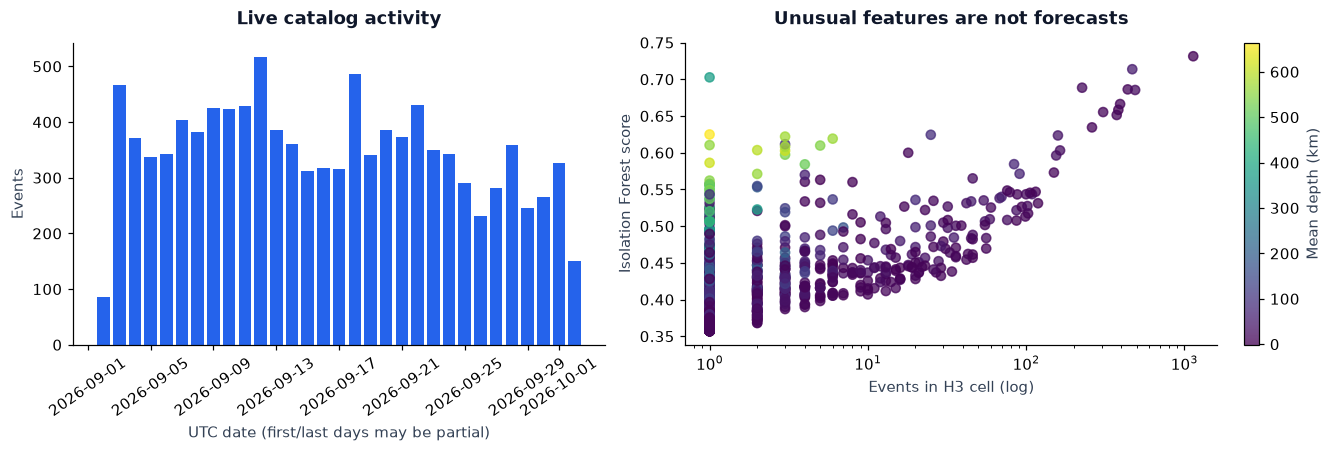

USGS feed generated (UTC): 2026-10-02 17:36:33+00:00
Missing magnitude records: 0


In [8]:
from cognition import style_plots
import matplotlib.pyplot as plt
style_plots()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
times = pd.to_datetime(eq.time, unit="ms", utc=True)
daily = eq.assign(day=times.dt.floor("D")).groupby("day").size()
axes[0].bar(daily.index, daily.values, color="#2563eb")
axes[0].set(xlabel="UTC date (first/last days may be partial)", ylabel="Events", title="Live catalog activity")
axes[0].tick_params(axis="x", rotation=35)
points = axes[1].scatter(agg['count'], agg.anomaly_score, c=agg.mean_depth, cmap="viridis", alpha=.75)
axes[1].set(xscale="log", xlabel="Events in H3 cell (log)", ylabel="Isolation Forest score",
            title="Unusual features are not forecasts")
fig.colorbar(points, ax=axes[1], label="Mean depth (km)")
plt.show()
print("USGS feed generated (UTC):", pd.to_datetime(feed['metadata']['generated'], unit='ms', utc=True))
print("Missing magnitude records:", eq.mag.isna().sum())

**Challenge:** find a high-score, low-count cell. Which other feature could explain its score? Counts also reflect sensor coverage, reporting practices, and the chosen time window.